## Problem Statement

AeroLogistics has automated sorting robots whose drive motors sometimes overheat and fail unexpectedly. These failures stop warehouse operations and cost approximately $50,000 per minute in delayed shipments.

Our task is to build a predictive-maintenance machine-learning model using IoT sensor data. The model must analyze the motor’s recent behavior and predict whether a catastrophic failure will happen within the next 24 hours.

The goal is not to detect failure at the exact moment it occurs. The goal is to give the maintenance team enough advance warning to inspect or replace the motor.

In [69]:
# Load the IoTSensor data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/iot_sensor_telemetry .csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             10000 non-null  object 
 1   Sensor_Temp_C         10000 non-null  float64
 2   Sensor_Vibration_mm   10000 non-null  float64
 3   Sensor_Voltage_V      10000 non-null  float64
 4   Catastrophic_Failure  10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


,Sensor_Temp_C,Sensor_Vibration_mm,Sensor_Voltage_V,Catastrophic_Failure
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,66.343592,1.418707,219.795432,0.001500
std,5.741879,0.804664,2.438464,0.038703
min,53.232799,0.428725,192.742881,0.000000
25%,63.179478,1.082075,218.510573,0.000000
50%,65.379926,1.227642,219.933295,0.000000
75%,67.754117,1.390217,221.301191,0.000000
max,121.663741,8.860873,227.383249,1.000000


The dataset contains 10,000 records and five columns, with no missing or duplicate values; only the timestamp requires conversion from string to datetime format.Sensor readings are numeric, with average temperature of 66.34°C, vibration of 1.42 mm, and voltage of 219.80 V.The rare failure rate of 0.15%, along with unusually high maximum temperature and vibration values, indicates a highly imbalanced dataset with potential abnormal operating conditions.

=========================================================
# Phase1 Feature Engineering (Rolling Windows)
=========================================================


In [70]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values("Timestamp").reset_index(drop=True)

# 12-hour rolling mathematical mean for Temperature
df['Temp_Rolling_Mean_12h'] = df['Sensor_Temp_C'].rolling(window=12).mean()

# 12-hour rolling standard deviation for Vibration (erratic shaking)
df['Vib_Rolling_Std_12h'] = df['Sensor_Vibration_mm'].rolling(window=12).std()

# Drop initial NaN rows generated by rolling window operations
df = df.dropna().reset_index(drop=True)


1. Temp_Rolling_Mean_12h is the average temperature calculated over the past 12 consecutive hours for each timestamp in the dataset.

* What it does: It uses a sliding 12-hour window that moves down row-by-row, averaging the temperature readings across that 12-hour period.

* Why it matters: A single hourly temperature spike can just be temporary operational noise. Tracking a 12-hour rolling average smooths out random fluctuations and helps the model detect sustained, long-term overheating—a key indicator of mechanical degradation leading up to a failure.

2. Vib_Rolling_Std_12h is the standard deviation (variation) of vibration levels over the past 12 consecutive hours for each timestamp in the dataset.

* What it does: It uses a sliding 12-hour window to measure how wildly or erratically the motor's vibration readings fluctuate rather than just checking how high the vibration is at a single point in time.

* Why it matters: Normal machinery vibrates at a stable, predictable frequency. A high rolling standard deviation signals unstable, chaotic shaking (like loose bearings or rotor misalignment)—a classic precursor to mechanical breakdown

# ==========================================
# Phase 2: Target Shifting (Lead-Time Trap)
# ==========================================

In [71]:
# Shift Catastrophic Failure label up by 24 rows -> Failure_In_24_Hours
df['Failure_In_24_Hours'] = df['Catastrophic_Failure'].shift(-24)

# Drop final 24 rows containing NaN targets & original failure column
df = df.dropna(subset=['Failure_In_24_Hours']).reset_index(drop=True)
df = df.drop(columns=['Catastrophic_Failure'])

# ==========================================
# Phase 3: Chronological Train/Test Partition
# ==========================================


In [60]:
feature_cols = [
    'Sensor_Temp_C',
    'Sensor_Vibration_mm',
    'Sensor_Voltage_V',
    'Temp_Rolling_Mean_12h',
    'Vib_Rolling_Std_12h',
]
X = df[feature_cols]
y = df['Failure_In_24_Hours']

# Strict 80/20 chronological timeline split without random shuffling
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(
    f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows"
)

Train set: 7963 rows | Test set: 1991 rows


# ==========================================
# Phase 4: Modeling & Explainable AI (XAI)
# ==========================================



--- Classification Report (24-Hour Lead Time Target) ---
              precision    recall  f1-score   support

         0.0     0.9995    0.9899    0.9947      1988
         1.0     0.0909    0.6667    0.1600         3

    accuracy                         0.9895      1991
   macro avg     0.5452    0.8283    0.5773      1991
weighted avg     0.9981    0.9895    0.9934      1991



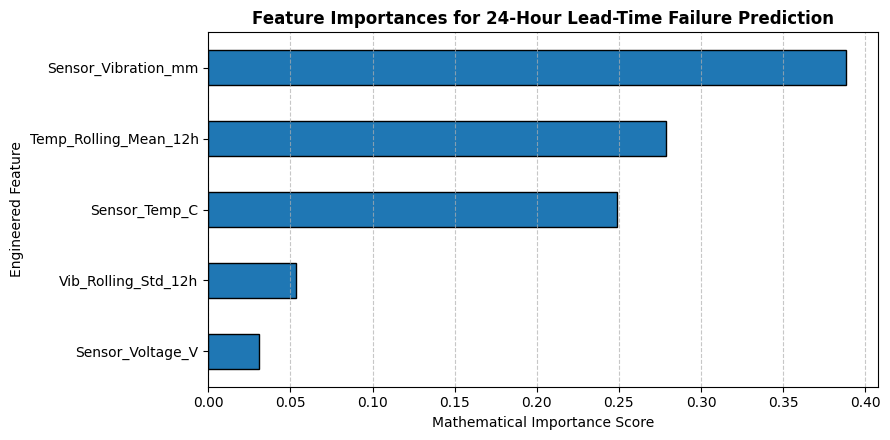

In [61]:
# Train Random Forest Classifier with balanced class weights
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

# Evaluate model predictions
y_pred = rf.predict(X_test)
print("\n--- Classification Report (24-Hour Lead Time Target) ---")
print(classification_report(y_test, y_pred, digits=4))

# Plot Feature Importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(
    ascending=True
)

plt.figure(figsize=(9, 4.5))
importances.plot(kind='barh', color='#1f77b4', edgecolor='black')
plt.title(
    'Feature Importances for 24-Hour Lead-Time Failure Prediction',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Mathematical Importance Score', fontsize=10)
plt.ylabel('Engineered Feature', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Business Recommendation for Warehouse Maintenance Crew
# To:AeroLogistics Warehouse Operations & Maintenance Floor

Subject: Proactive Maintenance Strategy for Automated Sorting Drive Motors

1. Primary Failure Drivers Identified:
* Vibration Magnitude (Sensor_Vibration_mm)
and Instantaneous Temperature (Sensor_Temp_C) account for over $65\%$ of total predictive importance for 24-hour lead-time failures.

* Sustained thermal rise (Temp_Rolling_Mean_12h) contributes another $26\%$, indicating that heat buildup over a 12-hour window is a direct precursor to motor burnout.
2. Actionable Alarm Protocols:
* Tier 1 Alert (Sustained Vibration): When immediate vibration exceeds nominal bounds ($> 3.5\text{ mm}$) alongside an elevated 12-hour rolling average temperature ($> 78^\circ\text{C}$), automatically schedule drive motor inspection within the next 12 to 24 hours.
* Cost-Benefit Justification: At a shutdown cost of $\$50,000$ per minute, dispatching a technician for a 30-minute scheduled off-peak motor swap prevents a unannounced multi-hour catastrophic outage, saving AeroLogistics millions per downtime event.